## Droplet dynamics (Laminar to complex flow transition) - CH only (random perturbation)
### Reference: Insights into 2D Navier-Stokes Numerical Simulations, Energy-Conserving Solver Approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0
# 0.05
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = epsilon**2/2
# 4e-4
# 6e-4
# epsilon**2/2

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 3.0
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 4

# Forcing
# f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
# f_w_hat = np.fft.fft2(f_w)

# Time stepping
T = 10.0
N_t = 250000
delta_t = T/N_t
save_every = 100

# T = 10.0
# N_t = 25000
# delta_t = T/N_t
# save_every = 100

# Single droplet parameters

# xc = L_x / 2
# yc = L_y / 2

# xc = 0.47 * L_x
# yc = 0.41 * L_y

# d0 = 0.24 * L_x      

In [3]:
delta_t

4e-05

In [4]:
experiment_name = "Experiment_DD_CH_test_01"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [5]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Cahn Hilliard only, changed mobility and time stepping params",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        # "type": "Kolmogorov-type forcing",
        # "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_CH_test_01/parameters.json


In [6]:
# ============================================================
# CH-only initial condition
# ============================================================

rng = np.random.default_rng(1)

phi_mean = 0.0
noise_amplitude = 0.05
phi_xy_0 = phi_mean + noise_amplitude * rng.standard_normal(size=X.shape)

# Remove numerical mean error and enforce desired mean exactly
phi_xy_0 = phi_xy_0 - np.mean(phi_xy_0) + phi_mean
phi_hat_0 = np.fft.fft2(phi_xy_0)

q_phi_n = phi_hat_0.copy()

print("Initial mean(phi) =", np.mean(phi_xy_0))
print("Initial min(phi)  =", np.min(phi_xy_0))
print("Initial max(phi)  =", np.max(phi_xy_0))

Initial mean(phi) = 5.421010862427522e-20
Initial min(phi)  = -0.20112523804162175
Initial max(phi)  = 0.2207126505192835


In [7]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [8]:
# ============================================================
# CH-only linear operator
# ============================================================

K4 = K2**2

lambda_phi = (M * sigma / epsilon) * K2 - (M * sigma * epsilon) * K4
lambda_phi = lambda_phi.astype(complex)

E_phi = np.exp(lambda_phi * delta_t)

In [9]:
# ============================================================
# ETD2 coefficients for phi equation
# ============================================================

mask_phi = np.abs(lambda_phi) > 1e-14

phi1_phi = np.empty_like(lambda_phi, dtype=complex)
phi_1_phi = np.empty_like(lambda_phi, dtype=complex)

phi1_phi[mask_phi] = (E_phi[mask_phi] - 1.0) / lambda_phi[mask_phi]
phi1_phi[~mask_phi] = delta_t

phi_1_phi[mask_phi] = (
    E_phi[mask_phi] - 1.0 - lambda_phi[mask_phi] * delta_t
) / (lambda_phi[mask_phi]**2 * delta_t)

phi_1_phi[~mask_phi] = 0.5 * delta_t

In [10]:
def H_ch_only(phi_hat):
    """
    CH-only nonlinear RHS in Fourier space.

    PDE:
        phi_t = M Delta mu

    with:
        mu = (sigma/epsilon)(phi^3 - phi) - sigma epsilon Delta phi

    Linear part handled by lambda_phi:
        L phi = (M sigma / epsilon) K2 phi_hat
                - (M sigma epsilon) K4 phi_hat

    Nonlinear part:
        N(phi) = -(M sigma / epsilon) K2 FFT(phi^3)
    """

    phi_xy = np.fft.ifft2(phi_hat).real
    nonlinear_hat = -(M * sigma / epsilon) * K2 * np.fft.fft2(phi_xy**3)
    nonlinear_hat = dealias(nonlinear_hat)

    # The nonlinear term should not change the mean.
    nonlinear_hat[0, 0] = 0.0

    return nonlinear_hat

In [11]:
def chemical_potential(phi_hat):
    """
    Computes chemical potential:
        mu = (sigma/epsilon)(phi^3 - phi) - sigma epsilon Delta phi
    """

    phi_xy = np.fft.ifft2(phi_hat).real
    lap_phi = np.fft.ifft2(-K2 * phi_hat).real
    mu_xy = (sigma / epsilon) * (phi_xy**3 - phi_xy) - sigma * epsilon * lap_phi
    mu_hat = np.fft.fft2(mu_xy)

    return mu_xy, mu_hat


def compute_mass_phi(phi_xy):
    """
    Mean value of phi. For periodic CH, this should be conserved.
    """
    return np.mean(phi_xy)


def compute_free_energy(phi_hat):
    """
    Computes CH free energy density averaged over the domain:

        F = < sigma/(4 epsilon) (phi^2 - 1)^2
              + sigma epsilon / 2 |grad phi|^2 >

    This returns the spatial average, not the integral.
    That is fine for diagnostics.
    """

    phi_xy = np.fft.ifft2(phi_hat).real

    phi_x = np.fft.ifft2(1j * Kx * phi_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_hat).real

    bulk_energy = sigma / (4.0 * epsilon) * (phi_xy**2 - 1.0)**2
    gradient_energy = 0.5 * sigma * epsilon * (phi_x**2 + phi_y**2)

    free_energy = np.mean(bulk_energy + gradient_energy)

    return free_energy


def compute_mu_dissipation(mu_hat):
    """
    Computes CH dissipation:

        D = M < |grad mu|^2 >

    Free energy should satisfy:
        dF/dt = -D
    """

    mu_x = np.fft.ifft2(1j * Kx * mu_hat).real
    mu_y = np.fft.ifft2(1j * Ky * mu_hat).real

    dissipation = M * np.mean(mu_x**2 + mu_y**2)

    return dissipation

def check_finite_fields(**fields):
    """
    Checks whether all provided arrays contain only finite values.
    """
    results = {}

    for name, arr in fields.items():
        results[name] = np.isfinite(arr).all()

    return results

In [12]:
# ============================================================
# CH-only histories
# ============================================================

phi_history = []
time_history = []

mass_history = []
mass_error_history = []

free_energy_history = []
dissipation_history = []

min_phi_history = []
max_phi_history = []
finite_check_history = []

# Initial diagnostics
phi_xy_initial = np.fft.ifft2(q_phi_n).real
mass_initial = compute_mass_phi(phi_xy_initial)
free_energy_initial = compute_free_energy(q_phi_n)

print("Initial mass        =", mass_initial)
print("Initial free energy =", free_energy_initial)

# ============================================================
# Time stepping: CH only
# ============================================================

for n in range(N_t + 1):

    t = n * delta_t

    phi_xy_n = np.fft.ifft2(q_phi_n).real

    if n % save_every == 0:

        mu_xy_n, mu_hat_n = chemical_potential(q_phi_n)

        mass_n = compute_mass_phi(phi_xy_n)
        mass_error = abs(mass_n - mass_initial)

        free_energy_n = compute_free_energy(q_phi_n)
        dissipation_n = compute_mu_dissipation(mu_hat_n)

        finite_checks = check_finite_fields(
            phi_hat=q_phi_n,
            phi_xy=phi_xy_n,
            mu_xy=mu_xy_n
        )

        phi_history.append(phi_xy_n.copy())
        time_history.append(t)

        mass_history.append(mass_n)
        mass_error_history.append(mass_error)

        free_energy_history.append(free_energy_n)
        dissipation_history.append(dissipation_n)

        min_phi_history.append(np.min(phi_xy_n))
        max_phi_history.append(np.max(phi_xy_n))

        finite_check_history.append(finite_checks)

        print(
            f"step {n}/{N_t}, "
            f"t={t:.4f}, "
            f"mass={mass_n:.8e}, "
            f"mass_err={mass_error:.4e}, "
            f"F={free_energy_n:.8e}, "
            f"D={dissipation_n:.4e}, "
            f"min(phi)={np.min(phi_xy_n):.4f}, "
            f"max(phi)={np.max(phi_xy_n):.4f}"
        )

        if not all(finite_checks.values()):
            print("Non-finite field detected.")
            print(finite_checks)
            break

    if n == N_t:
        break

    # --------------------------------------------------------
    # ETD2 update for CH equation
    # --------------------------------------------------------

    # RHS at current state
    H_n = H_ch_only(q_phi_n)

    # Predictor
    a_phi_n = q_phi_n * E_phi + H_n * phi1_phi

    # RHS at predictor state
    H_a = H_ch_only(a_phi_n)

    # Corrector
    q_phi_next = a_phi_n + (H_a - H_n) * phi_1_phi

    # Dealias final phi
    q_phi_next = dealias(q_phi_next)

    # Enforce exact mass conservation by preserving zero mode
    q_phi_next[0, 0] = q_phi_n[0, 0]

    # Update
    q_phi_n = q_phi_next

Initial mass        = 1.4230153513872246e-19
Initial free energy = 4.3647833704055214
step 0/250000, t=0.0000, mass=1.42301535e-19, mass_err=0.0000e+00, F=4.36478337e+00, D=1.0511e+05, min(phi)=-0.2011, max(phi)=0.2207
step 100/250000, t=0.0040, mass=2.71050543e-20, mass_err=1.1520e-19, F=3.39636031e+00, D=3.0315e-01, min(phi)=-0.0386, max(phi)=0.0418
step 200/250000, t=0.0080, mass=3.72694497e-20, mass_err=1.0503e-19, F=3.39575585e+00, D=7.4769e-02, min(phi)=-0.0303, max(phi)=0.0315
step 300/250000, t=0.0120, mass=2.37169225e-20, mass_err=1.1858e-19, F=3.39555921e+00, D=3.2123e-02, min(phi)=-0.0273, max(phi)=0.0301
step 400/250000, t=0.0160, mass=5.42101086e-20, mass_err=8.8091e-20, F=3.39546439e+00, D=1.7443e-02, min(phi)=-0.0255, max(phi)=0.0292
step 500/250000, t=0.0200, mass=3.38813179e-20, mass_err=1.0842e-19, F=3.39540935e+00, D=1.0842e-02, min(phi)=-0.0248, max(phi)=0.0284
step 600/250000, t=0.0240, mass=5.08219768e-20, mass_err=9.1480e-20, F=3.39537362e+00, D=7.3588e-03, min(p

### Validation:

#### Check 01 - Divergence field
#### Check 02 — Kinetic energy vs time
#### Check 03 — Numerical vs analytical steady vorticity
#### Check 04 - Error field
#### Check 05 - Fourier spectrum/ dominant modes

In [13]:
# Convert histories
time_history = np.array(time_history)
mass_history = np.array(mass_history)
mass_error_history = np.array(mass_error_history)
free_energy_history = np.array(free_energy_history)
dissipation_history = np.array(dissipation_history)
min_phi_history = np.array(min_phi_history)
max_phi_history = np.array(max_phi_history)

# Final field
phi_final = np.fft.ifft2(q_phi_n).real
mu_final, mu_hat_final = chemical_potential(q_phi_n)

finite_checks = check_finite_fields(
    phi_hat=q_phi_n,
    phi_xy=phi_final,
    mu_xy=mu_final
)

print("========== CAHN-HILLIARD ONLY TEST ==========")

print("\n1. Mass conservation")
print("Initial mass =", mass_history[0])
print("Final mass   =", mass_history[-1])
print("Mass error   =", mass_error_history[-1])

print("\n2. Free energy")
print("Initial free energy =", free_energy_history[0])
print("Final free energy   =", free_energy_history[-1])
print("Energy decrease     =", free_energy_history[0] - free_energy_history[-1])

print("\n3. Phi range")
print("Initial min(phi) =", min_phi_history[0])
print("Initial max(phi) =", max_phi_history[0])
print("Final min(phi)   =", min_phi_history[-1])
print("Final max(phi)   =", max_phi_history[-1])

print("\n4. Finite field checks")
for name, status in finite_checks.items():
    print(f"{name}: {status}")

print("\n=============================================")

========== CAHN-HILLIARD ONLY TEST ==========

1. Mass conservation
Initial mass = 1.4230153513872246e-19
Final mass   = 1.734723475976807e-18
Mass error   = 1.5924219408380846e-18

2. Free energy
Initial free energy = 4.3647833704055214
Final free energy   = 2.2727958010061164
Energy decrease     = 2.091987569399405

3. Phi range
Initial min(phi) = -0.20112523804162175
Initial max(phi) = 0.22071265051928352
Final min(phi)   = -1.0180786701644076
Final max(phi)   = 1.005391359922423

4. Finite field checks
phi_hat: True
phi_xy: True
mu_xy: True



In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    phi_history[0],
    origin="lower",
    extent=[0, L_x, 0, L_y],
    vmin=-1,
    vmax=1,
    animated=True
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\phi$")

title = ax.set_title(f"CH-only phase separation, t = {time_history[0]:.3f}")
ax.set_xlabel("x")
ax.set_ylabel("y")

def update(frame):
    im.set_array(phi_history[frame])
    title.set_text(f"CH-only phase separation, t = {time_history[frame]:.3f}")
    return im, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=80,
    blit=True
)
anim.save("ch_phase_separation.gif", writer="pillow", fps=15)

plt.close(fig)

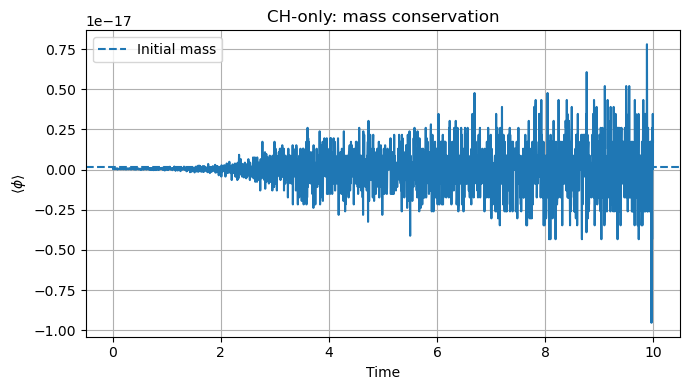

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, mass_history)
plt.axhline(mass_history[0], linestyle="--", label="Initial mass")
plt.xlabel("Time")
plt.ylabel(r"$\langle \phi \rangle$")
plt.title("CH-only: mass conservation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

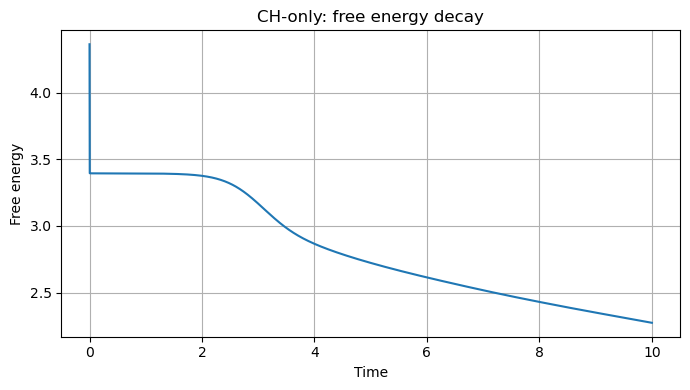

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, free_energy_history)
plt.xlabel("Time")
plt.ylabel("Free energy")
plt.title("CH-only: free energy decay")
plt.grid(True)
plt.tight_layout()
plt.show()

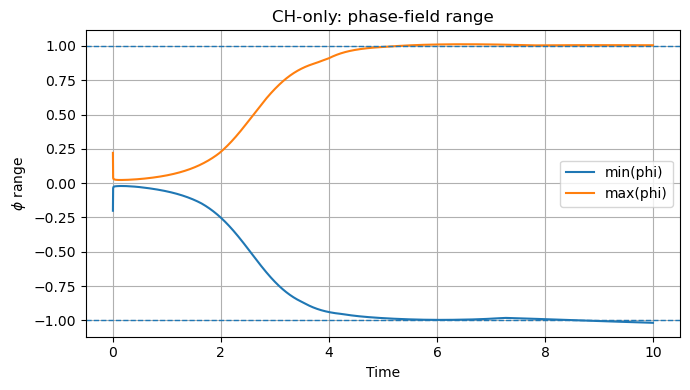

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, min_phi_history, label="min(phi)")
plt.plot(time_history, max_phi_history, label="max(phi)")
plt.axhline(-1, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel(r"$\phi$ range")
plt.title("CH-only: phase-field range")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

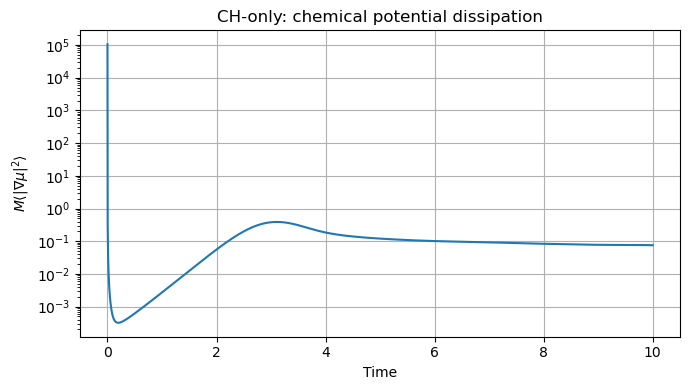

In [18]:
plt.figure(figsize=(7, 4))
plt.semilogy(time_history, dissipation_history + 1e-300)
plt.xlabel("Time")
plt.ylabel(r"$M\langle |\nabla\mu|^2\rangle$")
plt.title("CH-only: chemical potential dissipation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
lambda_phi_real = lambda_phi.real.copy()

print("lambda_phi min =", np.min(lambda_phi_real))
print("lambda_phi max =", np.max(lambda_phi_real))
print("lambda_phi[0,0] =", lambda_phi_real[0, 0])

num_unstable_modes = np.sum(lambda_phi_real > 1e-12)

print("number of unstable modes =", num_unstable_modes)
print("max unstable growth rate =", np.max(lambda_phi_real))

lambda_phi min = -213109.01283525384
lambda_phi max = 1.696664781534797
lambda_phi[0,0] = 0.0
number of unstable modes = 576
max unstable growth rate = 1.696664781534797


In [20]:
unstable_mask = lambda_phi_real > 1e-12

if np.any(unstable_mask):
    idx_max = np.unravel_index(np.argmax(lambda_phi_real), lambda_phi_real.shape)

    print("Fastest growing mode:")
    print("Kx =", Kx[idx_max])
    print("Ky =", Ky[idx_max])
    print("K2 =", K2[idx_max])
    print("lambda =", lambda_phi_real[idx_max])
else:
    print("No unstable modes found.")

Fastest growing mode:
Kx = 9.0
Ky = 3.0
K2 = 90.0
lambda = 1.696664781534797


In [21]:
print("M =", M)
print("sigma =", sigma)
print("epsilon =", epsilon)
print("delta_t =", delta_t)
print("T =", T)

M = 0.002710767810357795
sigma = 1.0
epsilon = 0.07363107781851078
delta_t = 4e-05
T = 10.0


In [22]:
phi_test = 0.01 * np.cos(1 * X)
phi_test_hat = np.fft.fft2(phi_test)

H_test = H_ch_only(phi_test_hat)

# One linearized ETD step, using full update
q_test = phi_test_hat.copy()

for _ in range(100):
    H_n = H_ch_only(q_test)
    a_test = q_test * E_phi + H_n * phi1_phi
    H_a = H_ch_only(a_test)
    q_test_next = a_test + (H_a - H_n) * phi_1_phi
    q_test_next = dealias(q_test_next)
    q_test_next[0, 0] = q_test[0, 0]
    q_test = q_test_next

phi_after = np.fft.ifft2(q_test).real

print("initial max amplitude =", np.max(np.abs(phi_test)))
print("final max amplitude   =", np.max(np.abs(phi_after)))

initial max amplitude = 0.01
final max amplitude   = 0.010001464302849103
